In [1]:
# --- Core Libraries ---
import sys
import os

# --- Data Handling and Numerical Operations ---
import numpy as np
import pandas as pd

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning and Deep Learning ---
import tensorflow as tf

# 1. Introduction to TensorFlow Fundamentals

This section serves as a practical introduction to the core components of TensorFlow. We will explore the building blocks of this powerful library, focusing on:

- **Tensors:** The fundamental data structure in TensorFlow, similar to NumPy arrays but with added capabilities for GPU acceleration.
- **Variables:** Special tensors used to hold mutable state, such as the weights and biases of a machine learning model, which are updated during training.
- **Basic Operations:** Essential mathematical and manipulation operations that can be performed on tensors, forming the basis of all model computations.

The goal is to build a foundational understanding of how to create, manipulate, and operate on tensors, which is crucial before moving on to building and training models.

## **1.1. Tensor Creation: Constants and Variables**

In TensorFlow, data is represented using tensors. There are two main types:

- **`tf.constant`**: These are immutable tensors. Once their value is set, it cannot be changed. They are ideal for holding fixed data, such as input features or configuration parameters.
- **`tf.Variable`**: These are mutable tensors designed to store and update the state of your model. The primary use case for variables is to hold the model parameters (weights and biases) that are adjusted during the training process to minimize the loss function.

This subsection demonstrates how to create both types of tensors and highlights their fundamental difference in modifiability.

In [2]:
# Create a NumPy array, which is a familiar structure.
# This array is inherently modifiable.
array_a = np.array([[[1, 2],
                     [3, 4]],

                    [[5, 6],
                     [7, 8]]])

# Display the basic properties of the NumPy array.
print("--- NumPy Array Properties ---",
      f"Shape: {array_a.shape}",
      f"Data Type: {array_a.dtype}",
      sep="\n",
      end="\n\n"
)

# --- Demonstrating TensorFlow Constant Creation ---
# TensorFlow provides several convenient functions to create common tensors.
print("--- TensorFlow Constant Creation Examples ---",
    # Create a constant tensor from a list with a specific data type and shape.
    "From a list:\n" + str(tf.constant([1, 2, 3, 4], dtype=tf.int8, shape=(2, 2)).numpy()),
    # Create a tensor of all ones with a given shape.
    "Tensor of ones:\n" + str(tf.ones((2, 2, 2)).numpy()),
    # Create a tensor of ones with the same shape as an existing array/tensor.
    "Ones like another tensor:\n" + str(tf.ones_like(array_a).numpy()),
    # Create a tensor of all zeros.
    "Tensor of zeros:\n" + str(tf.zeros((2, 2, 2)).numpy()),
    # Create a tensor of zeros with the same shape as an existing array/tensor.
    "Zeros like another tensor:\n" + str(tf.zeros_like(array_a).numpy()),
    # Create a tensor filled with a specific scalar value.
    "Filled tensor:\n" + str(tf.fill([2, 2], value=7).numpy()),
sep="\n\n")

# --- Creating a TensorFlow Variable ---
# A tf.Variable holds state and can be updated. It's essential for model parameters.
print("--- TensorFlow Variable ---")
print(tf.Variable([1, 2, 3]))

--- NumPy Array Properties ---
Shape: (2, 2, 2)
Data Type: int64

--- TensorFlow Constant Creation Examples ---

From a list:
[[1 2]
 [3 4]]

Tensor of ones:
[[[1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]]]

Ones like another tensor:
[[[1 1]
  [1 1]]

 [[1 1]
  [1 1]]]

Tensor of zeros:
[[[0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]]]

Zeros like another tensor:
[[[0 0]
  [0 0]]

 [[0 0]
  [0 0]]]

Filled tensor:
[[7 7]
 [7 7]]
--- TensorFlow Variable ---
<tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([1, 2, 3], dtype=int32)>


In [3]:
# --- Immutability of `tf.constant` ---
# Create a constant tensor.
tensor_a = tf.constant(np.random.RandomState(13).binomial(10, 0.5, size=(2, 3, 3)), dtype=tf.int8)

# Attempting to modify an element of a constant tensor will raise an error.
# The `.assign()` method is used for updating variables, not constants.
try:
    tensor_a[0, 0, 0].assign(1)
except Exception as e:
    print(f"--- Attempting to Modify a `tf.constant` ---")
    print(f"Error: Constant tensors are immutable. The operation failed as expected.")
    print(f"Original tensor remains unchanged:\n{tensor_a.numpy()}\n")

# --- Mutability of `tf.Variable` ---
# Create a variable from the constant tensor. Variables are designed to be modified.
tensor_b = tf.Variable(tensor_a)

# Use the `.assign()` method to update a specific element of the variable.
# This operation succeeds because `tensor_b` is a `tf.Variable`.
print(f"--- Modifying a `tf.Variable` ---")
print(f"Original variable:\n{tensor_b.numpy()}\n")
tensor_b[0, 0, 0].assign(1)
print(f"Variable after modification:\n{tensor_b.numpy()}")

--- Attempting to Modify a `tf.constant` ---
Error: Constant tensors are immutable. The operation failed as expected.
Original tensor remains unchanged:
[[[6 4 6]
  [8 8 5]
  [5 6 6]]

 [[6 2 4]
  [3 7 4]
  [6 4 4]]]

--- Modifying a `tf.Variable` ---
Original variable:
[[[6 4 6]
  [8 8 5]
  [5 6 6]]

 [[6 2 4]
  [3 7 4]
  [6 4 4]]]

Variable after modification:
[[[1 4 6]
  [8 8 5]
  [5 6 6]]

 [[6 2 4]
  [3 7 4]
  [6 4 4]]]


## **1.2. Basic Tensor Operations**

Just like with NumPy arrays, TensorFlow allows for a wide range of mathematical operations on tensors. These operations are highly optimized for performance, especially on GPUs. This section covers fundamental element-wise and matrix operations that are the building blocks of any machine learning model's forward pass.

We will demonstrate:
- Scalar multiplication
- Transposition
- Concatenation
- Element-wise arithmetic (addition, subtraction, multiplication)
- Matrix multiplication (dot product)

In [4]:
# Define two constant tensors for our operations.
# Using float16 for memory efficiency where high precision is not critical.
tensor_a = tf.constant([1, 2, 3, 4], dtype=tf.float16, shape=[2, 2])
# An identity matrix is useful for many linear algebra operations.
tensor_b = tf.constant(np.identity(2), dtype=tf.float16)

print(f"--- Initial Tensors --- \nTensor A:\n{tensor_a.numpy()} \n\nTensor B (Identity Matrix):\n{tensor_b.numpy()}\n")

print(
    "--- Tensor Operations ---",
    # Scalar multiplication scales all elements of the tensor.
    f"Scalar Multiplication (B * 5):\n{ (tensor_b * 5).numpy() }",
    # Transposing swaps the axes of a tensor.
    f"Transpose of A:\n{ tf.transpose(tensor_a).numpy() }",
    # Concatenation joins tensors along a specified axis. Here, we stack them vertically (axis=0).
    f"Concatenation of A with itself (axis=0):\n{ tf.concat([tensor_a, tensor_a], axis=0).numpy() }",
    # Element-wise operations are performed between corresponding elements of tensors.
    f"Element-wise Addition (A + B):\n{ tf.add(tensor_a, tensor_b).numpy() }",
    f"Element-wise Subtraction (A - B):\n{ tf.subtract(tensor_a, tensor_b).numpy() }",
    f"Element-wise Multiplication (A * B):\n{ tf.multiply(tensor_a, tensor_b).numpy() }",
    # Matrix multiplication follows the rules of linear algebra (dot product).
    f"Matrix Multiplication (A @ B):\n{ tf.matmul(tensor_a, tensor_b).numpy() }",
    sep="\n\n"
)

--- Initial Tensors --- 
Tensor A:
[[1. 2.]
 [3. 4.]] 

Tensor B (Identity Matrix):
[[1. 0.]
 [0. 1.]]

--- Tensor Operations ---

Scalar Multiplication (B * 5):
[[5. 0.]
 [0. 5.]]

Transpose of A:
[[1. 3.]
 [2. 4.]]

Concatenation of A with itself (axis=0):
[[1. 2.]
 [3. 4.]
 [1. 2.]
 [3. 4.]]

Element-wise Addition (A + B):
[[2. 2.]
 [3. 5.]]

Element-wise Subtraction (A - B):
[[0. 2.]
 [3. 3.]]

Element-wise Multiplication (A * B):
[[1. 0.]
 [0. 4.]]

Matrix Multiplication (A @ B):
[[1. 2.]
 [3. 4.]]


In [5]:
# --- Demonstrating Dimensional Aggregation (Reduction) ---
# Reduction operations summarize tensor data along one or more axes.
# Create a 3D tensor to illustrate reduction along different axes.
ones_tensor = tf.ones([2, 3, 4]) # Shape: (depth, height, width)

print("--- Original 3D Tensor of Ones (Shape: 2, 3, 4) ---\n")

# `tf.reduce_sum` is a common reduction operation.
print(
    # axis=0: Sums the elements across the 'depth' dimension.
    # The two 3x4 matrices are added together element-wise.
    f"Sum along axis=0 (Result Shape: 3x4):\n{tf.reduce_sum(ones_tensor, axis=0).numpy()}",

    # axis=1: Sums the elements across the 'height' (rows) dimension for each matrix.
    f"Sum along axis=1 (Result Shape: 2x4):\n{tf.reduce_sum(ones_tensor, axis=1).numpy()}",

    # axis=2: Sums the elements across the 'width' (columns) dimension for each matrix.
    f"Sum along axis=2 (Result Shape: 2x3):\n{tf.reduce_sum(ones_tensor, axis=2).numpy()}",

    sep="\n\n"
)

--- Original 3D Tensor of Ones (Shape: 2, 3, 4) ---

Sum along axis=0 (Result Shape: 3x4):
[[2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]]

Sum along axis=1 (Result Shape: 2x4):
[[3. 3. 3. 3.]
 [3. 3. 3. 3.]]

Sum along axis=2 (Result Shape: 2x3):
[[4. 4. 4.]
 [4. 4. 4.]]


## **1.3. Tensor Slicing and Indexing**

Slicing and indexing are essential for accessing and manipulating specific parts of a tensor. The syntax is very similar to NumPy, making it intuitive for those familiar with the library. This section provides a demonstration of how to select elements, rows, columns, and sub-tensors from both 2D (matrices) and 3D tensors.

### **Slicing a 2D Tensor (Matrix)**

In [6]:
# Create a base 2D tensor (a 5x5 matrix) for slicing demonstrations.
# We start with a 1D range and reshape it.
tensor_a = tf.Variable(np.arange(25))
tensor_a = tf.reshape(tensor_a, shape=[5, 5])
print("--- Base 5x5 Matrix for Slicing ---")
tensor_a.numpy()

--- Base 5x5 Matrix for Slicing ---


array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [7]:
# --- Demonstrating various slicing techniques on the 2D matrix ---
print(
    # Get a single element at a specific index (row 0, column 0).
    f"Get a single element [0, 0]: {tensor_a[0, 0].numpy()}",

    # Get an entire row (the first row).
    f"Get the first row [0]: {tensor_a[0].numpy()}",

    # Get elements from the first row with a step (every 3rd element).
    f"Get elements from the first row with a step [0, ::3]: {tensor_a[0, ::3].numpy()}",

    # Get a slice of continuous rows (the first two rows).
    f"Get the first two rows [:2]:\n{tensor_a[:2].numpy()}",

    # Get non-continuous rows using a step (every 2nd row, up to the 3rd).
    f"Get non-continuous rows [:3:2, :]:\n{tensor_a[:3:2, :].numpy()}",

    # Slice a sub-matrix by specifying row and column ranges.
    f"Slice a sub-matrix [2:4, 1:3]:\n{tensor_a[2:4, 1:3].numpy()}",

    sep="\n\n"
)

Get a single element [0, 0]: 0

Get the first row [0]: [0 1 2 3 4]

Get elements from the first row with a step [0, ::3]: [0 3]

Get the first two rows [:2]:
[[0 1 2 3 4]
 [5 6 7 8 9]]

Get non-continuous rows [:3:2, :]:
[[ 0  1  2  3  4]
 [10 11 12 13 14]]

Slice a sub-matrix [2:4, 1:3]:
[[11 12]
 [16 17]]


### **Slicing a 3D Tensor**

In [8]:
# Create a 3D tensor for slicing demonstrations.
# The shape will be (2, 3, 3), representing 2 matrices of size 3x3.
tensor_b = tf.constant(np.arange(18).reshape(-1, 3, 3))
print("--- Base 3D Tensor (Shape: 2, 3, 3) ---")
print(f"Tensor Content:\n{tensor_b.numpy()}",
      f"Dimensions: {tensor_b.ndim}",
      f"Shape: {tensor_b.shape}",
      sep="\n\n")

--- Base 3D Tensor (Shape: 2, 3, 3) ---
Tensor Content:
[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]]

 [[ 9 10 11]
  [12 13 14]
  [15 16 17]]]

Dimensions: 3

Shape: (2, 3, 3)


In [9]:
# --- Demonstrating various slicing techniques on the 3D tensor ---
print(
    # Get a single scalar value from a specific location (matrix 0, row 1, column 1).
    f"Get a single element [0, 1, 1]: {tensor_b[0, 1, 1].numpy()}",

    # Extract a 1D vector (row 1 from matrix 0).
    f"Extract a 1D row [0, 1]: {tensor_b[0, 1].numpy()}",

    # Extract a 2D matrix by selecting the same row from all matrices in the tensor.
    f"Extract a 2D slice [:, 1]:\n{tensor_b[:, 1].numpy()}",

    # Perform a more complex slice across all three dimensions.
    # Selects all matrices, every second row, and the first two columns.
    f"Complex slice [:, ::2, :2]:\n{tensor_b[:, ::2, :2].numpy()}",

    sep="\n\n"
)

Get a single element [0, 1, 1]: 4

Extract a 1D row [0, 1]: [3 4 5]

Extract a 2D slice [:, 1]:
[[ 3  4  5]
 [12 13 14]]

Complex slice [:, ::2, :2]:
[[[ 0  1]
  [ 6  7]]

 [[ 9 10]
  [15 16]]]


# 2. Training a Simple Model with TensorFlow

Now that we have a grasp of the fundamentals, we can move on to a core machine learning task: training a model. This section demonstrates how to build and train a simple linear regression model from scratch using TensorFlow's low-level APIs.

The process involves several key steps:
1.  **Data Simulation:** We will create a synthetic dataset based on a known linear relationship, adding some random noise to mimic real-world data.
2.  **Model Definition:** We will define the structure of our linear model.
3.  **Loss Function:** We will define a function to measure how well our model's predictions match the actual data.
4.  **Training Loop:** We will implement a custom training loop that uses **gradient descent** to iteratively update the model's parameters (weight and bias) to minimize the loss. This involves using `tf.GradientTape` to automatically compute gradients.

This hands-on example provides a clear, step-by-step guide to the mechanics of a training process in TensorFlow.

## **2.1. Simple Linear Regression with Gradient Descent**

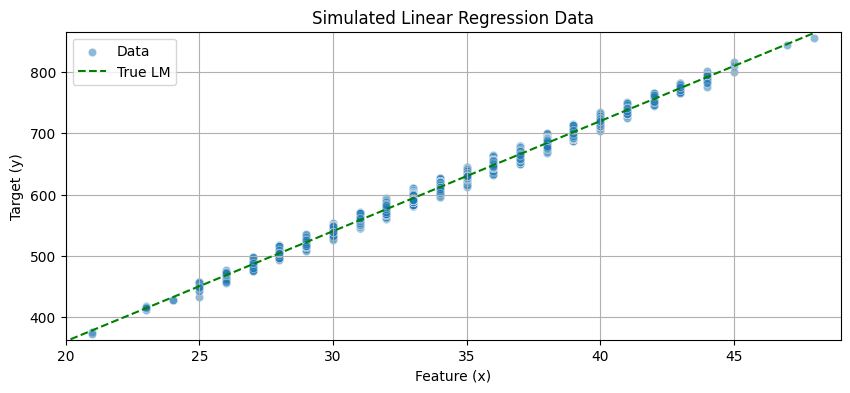

--- True Underlying Parameters ---
Weight: 18, Bias: 0


In [10]:
# --- Step 1: Simulate a Dataset for Linear Regression ---

# Use a fixed random state for reproducibility.
base_seed = np.random.RandomState(13)

# Define the "true" parameters of our linear model.
# Our goal is for the model to learn values close to these.
true_weight = base_seed.randint(0, 50, size=1)
true_bias = base_seed.randint(0, 10, size=1)

# Generate the input features 'x' from a binomial distribution.
# We cast to float64 to ensure compatibility with model parameters.
x = tf.constant(base_seed.binomial(n=50, p=0.70, size=10000), dtype=tf.float64)

# Generate the target variable 'y'.
# It's a linear function of 'x' plus some Gaussian noise to make it more realistic.
y = tf.constant((x * true_weight) + true_bias + base_seed.normal(loc=0, scale=5, size=x.shape[0]), dtype=tf.float64)

# --- Visualize the Simulated Data ---
fig, ax = plt.subplots(figsize=(10, 4))
# Create a scatter plot of the data points.
sns.scatterplot(y=y.numpy(), x=x.numpy(), ax=ax, alpha=0.5, label="Data")
# Plot the "true" line that the data was generated from.
ax.plot([0, max(x)], [true_bias[0], (max(x) * true_weight[0]) + true_bias[0]], "--g", label="True LM")
plt.title("Simulated Linear Regression Data")
plt.xlabel("Feature (x)")
plt.ylabel("Target (y)")
plt.xlim(np.min(x) - 1, np.max(x) + 1)
plt.ylim(np.min(y) - 10, np.max(y) + 10)
plt.legend()
plt.grid(True)
plt.show()

print(f"--- True Underlying Parameters ---")
print(f"Weight: {true_weight[0]}, Bias: {true_bias[0]}")

In [11]:
# --- Step 2: Define the Model and Loss Function ---

# The linear model function defines the forward pass.
def linear_model(bias, weights, x: np.array = x):
    """
    Computes the model's prediction using the linear equation: y = w*x + b.
    """
    return weights * x + bias

# The loss function quantifies how far the model's predictions are from the actual targets.
def loss_function(bias, weights, x: np.array = x, y: np.array = y):
    """
    Calculates the Mean Squared Error (MSE) between predicted and actual values.
    MSE is a standard loss function for regression tasks.
    """
    y_pred = linear_model(bias=bias, weights=weights, x=x)
    return tf.keras.losses.mse(y_true=y, y_pred=y_pred)

In [12]:
# --- Step 3: Implement the Custom Training Loop ---

# Initialize the model's parameters (weights and bias) as TensorFlow Variables.
# These will be updated during training. We start with arbitrary values.
bias = tf.Variable(0.0, name="b", dtype=tf.float64)
weight = tf.Variable(np.random.RandomState(17).random(1), name="w", dtype=tf.float64)

# Set up the optimizer. Adam is a popular and effective choice.
# The learning rate controls the size of the steps the optimizer takes.
optim = tf.keras.optimizers.Adam(learning_rate=0.1)
# Define the number of training iterations.
n_epochs = 3000

# The main training loop.
for epoch in range(n_epochs):
    # Use tf.GradientTape to automatically record operations for differentiation.
    with tf.GradientTape() as tape:
        # Calculate the loss for the current parameter values.
        loss = loss_function(bias, weight, x=x, y=y)

    # Compute the gradients of the loss with respect to the trainable parameters.
    gradients = tape.gradient(loss, [bias, weight])

    # Apply the gradients to the parameters to update them.
    # This is the core step of gradient descent.
    optim.apply_gradients(zip(gradients, [bias, weight]))

    # Periodically print the training progress.
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss: {loss.numpy():.2f}, Bias: {bias.numpy():.2f}, Weight: {weight.numpy()[0]:.2f}")

print(f"\n--- Training Complete ---")
print(f"Final Learned Parameters: Bias ({bias.numpy():.2f}), Weight({weight.numpy()[0]:.2f})")

Epoch 0: Loss: 386541.53, Bias: 0.10, Weight: 0.39
Epoch 500: Loss: 28.10, Bias: 17.18, Weight: 17.49
Epoch 1000: Loss: 27.51, Bias: 17.16, Weight: 17.51
Epoch 1500: Loss: 27.49, Bias: 17.09, Weight: 17.51
Epoch 2000: Loss: 27.47, Bias: 17.00, Weight: 17.52
Epoch 2500: Loss: 27.43, Bias: 16.88, Weight: 17.52

--- Training Complete ---
Final Learned Parameters: Bias (16.73), Weight(17.53)


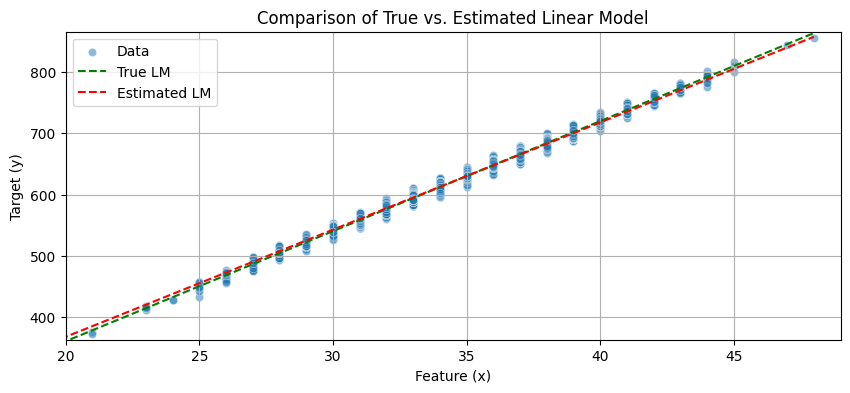

--- Parameter Comparison ---
True Parameters:      Weight -> 18.0000, Bias -> 0.0000
Estimated Parameters: Weight -> 17.5252, Bias -> 16.7271

Final Root Mean Squared Error (RMSE): 5.2336


In [13]:
# --- Step 4: Visualize and Evaluate the Results ---

fig, ax = plt.subplots(figsize=(10, 4))
# Plot the original data points.
sns.scatterplot(y=y.numpy(), x=x.numpy(), ax=ax, alpha=0.5, label="Data")
# Plot the true underlying line.
ax.plot([0, max(x)], [true_bias[0], (max(x) * true_weight[0]) + true_bias[0]], "--g", label="True LM")
# Plot the line our model has learned.
ax.plot([0, max(x)], [bias.numpy(), (max(x) * weight.numpy()[0]) + bias.numpy()], "--r", label="Estimated LM")

plt.title("Comparison of True vs. Estimated Linear Model")
plt.xlabel("Feature (x)")
plt.ylabel("Target (y)")
plt.xlim(np.min(x) - 1, np.max(x) + 1)
plt.ylim(np.min(y) - 10, np.max(y) + 10)
plt.legend()
plt.grid(True)
plt.show()

# --- Final Parameter Comparison and Error Metric ---
print(f"--- Parameter Comparison ---")
print(f"True Parameters:      Weight -> {true_weight[0]:.4f}, Bias -> {true_bias[0]:.4f}")
print(f"Estimated Parameters: Weight -> {weight.numpy()[0]:.4f}, Bias -> {bias.numpy():.4f}\n")

# Calculate the final Root Mean Squared Error (RMSE).
# This gives us a measure of the average prediction error in the original units.
rmse = tf.sqrt(loss)
print(f"Final Root Mean Squared Error (RMSE): {rmse.numpy():.4f}")

As a result, we can evidence that the proposed gradient descent model has a close weight to the real parameter. Although, it depicts a strong deviation from the real bias. As a result, this implementation has an RMSE of 5.22, which means that on average each estimated value deviates from the observed one by 5.23 units.

As a general explanation of this behaviour the discrepancy in the bias could be attributed to the gaussian noise in the data generating process for the target values.